# Aula 1: Ajustando uma reta

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv('Preços_de_casas.csv')
dados.head()

,Id,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,1,79.5224,1,79.3366,2,548,0,1027905.0
1,2,117.2398,0,0.0000,2,460,0,894795.0
2,3,85.4680,1,80.4514,2,608,0,1101855.0
3,4,89.2769,1,70.2324,1,642,0,690200.0
4,5,106.3705,1,97.8237,2,836,0,1232500.0


In [3]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [4]:
dados = dados.drop(columns='Id')

In [5]:
corr = dados.corr()

In [6]:
corr['preco_de_venda']

area_primeiro_andar               0.616557
existe_segundo_andar              0.138541
area_segundo_andar                0.305311
quantidade_banheiros              0.563132
capacidade_carros_garagem         0.640214
qualidade_da_cozinha_Excelente    0.496223
preco_de_venda                    1.000000
Name: preco_de_venda, dtype: float64

In [7]:
import  matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Text(0, 0.5, 'Preço de venda')

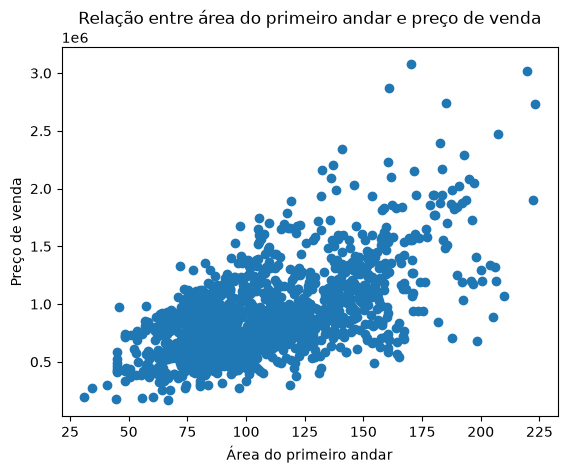

In [8]:
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.title("Relação entre área do primeiro andar e preço de venda")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço de venda")

Text(0, 0.5, 'Preço de venda')

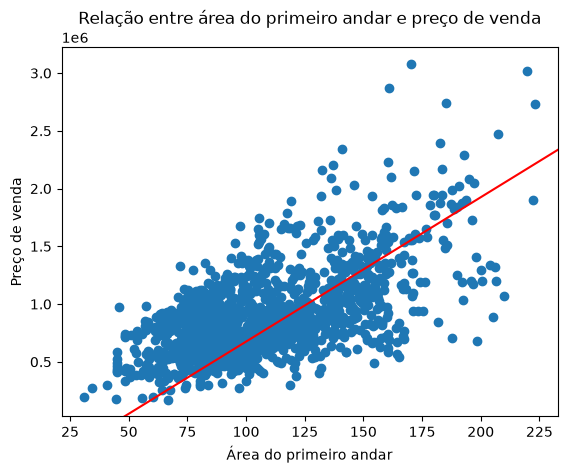

In [9]:
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.axline(xy1=(66, 250000), xy2=(190, 1800000), color='red')
plt.title("Relação entre área do primeiro andar e preço de venda")
plt.xlabel("Área do primeiro andar")
plt.ylabel("Preço de venda")

In [10]:
px.scatter(dados, x='area_primeiro_andar', y='preco_de_venda', trendline='ols', title="Relação entre área do primeiro andar e preço de venda", 
           trendline_color_override='red', labels={'area_primeiro_andar': 'Área do primeiro andar', 'preco_de_venda': 'Preço de venda'})

# Aula 2: Explicando a reta

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
y = dados['preco_de_venda']
x = dados.drop(columns='preco_de_venda')

In [13]:
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, test_size=0.3, random_state=230)

In [14]:
df_treino = pd.DataFrame(data=treino_x)
df_treino['preco_de_venda'] = treino_y

In [15]:
from statsmodels.formula.api import ols

In [16]:
modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data=df_treino).fit()

In [17]:
modelo_0.params

Intercept              152909.288334
area_primeiro_andar      6793.641641
dtype: float64

In [18]:
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Thu, 23 Jul 2026   Prob (F-statistic):          2.22e-105
Time:                        17:56:58   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

In [19]:
modelo_0.rsquared

np.float64(0.3772801099429788)

In [20]:
modelo_0.resid

1303   -193023.838744
326    -144522.356193
386     399612.747641
615     -68449.596607
236     166010.592859
            ...      
777     465872.680999
271    -497642.319788
723     461150.204718
560    -540482.733402
768     -37547.820756
Length: 1006, dtype: float64

Text(0.5, 1.0, 'Distribuição dos resíduos do modelo')

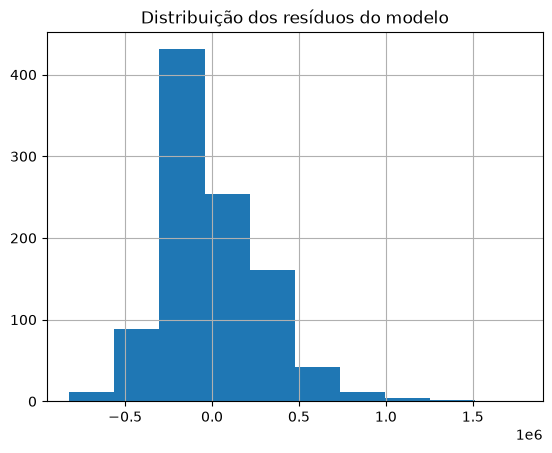

In [21]:
modelo_0.resid.hist()
plt.title("Distribuição dos resíduos do modelo")

In [22]:
y_pred = modelo_0.predict(teste_x)

In [23]:
from sklearn.metrics import r2_score

print("R²: ", r2_score(teste_y, y_pred))

R²:  0.38530928723202396


# Aula 3: Adicionando outros fatores

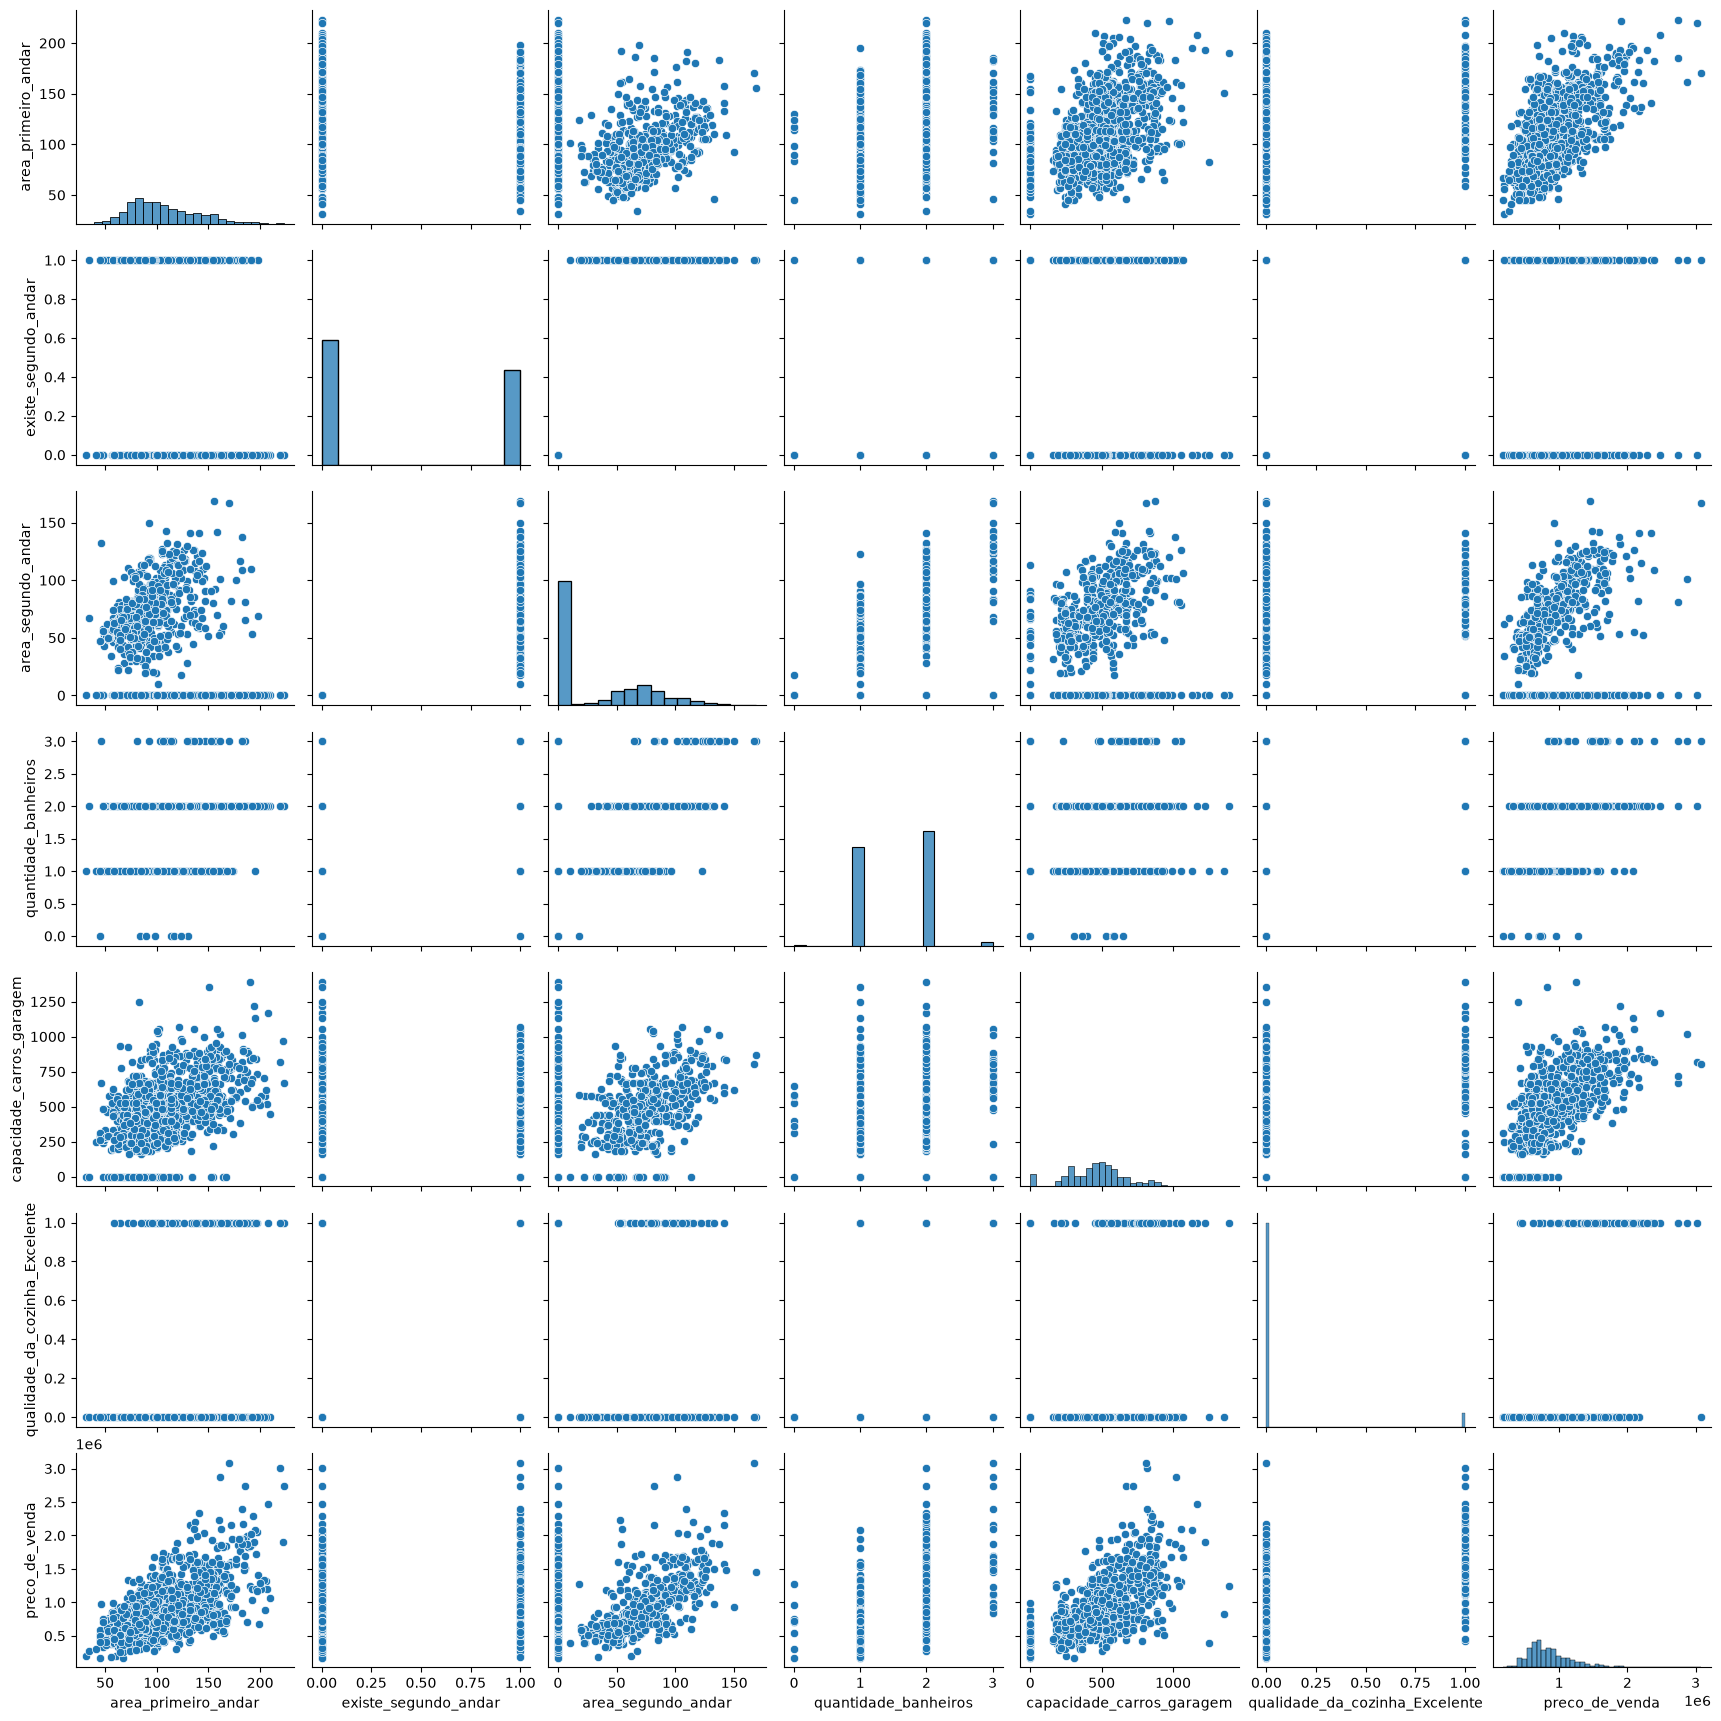

In [24]:
sns.pairplot(dados)

In [25]:
dados.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente', 'preco_de_venda'],
      dtype='str')

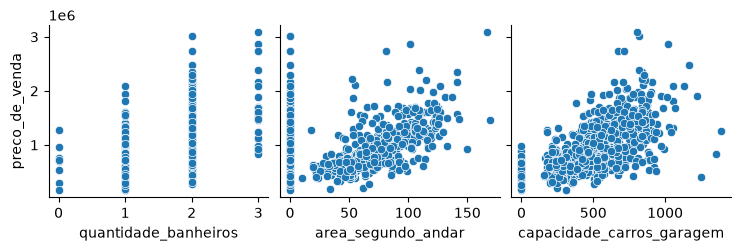

In [26]:
sns.pairplot(dados, y_vars=['preco_de_venda'], x_vars=['quantidade_banheiros', 'area_segundo_andar', 'capacidade_carros_garagem'])

In [27]:
import statsmodels.api as sm

In [28]:
treino_x = sm.add_constant(treino_x)

In [29]:
modelo_1 = sm.OLS(treino_y, treino_x[['const', 'area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
                                     'quantidade_banheiros', 'capacidade_carros_garagem',
                                     'qualidade_da_cozinha_Excelente']]).fit()

In [30]:
modelo_2 = sm.OLS(treino_y, treino_x[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                                     'quantidade_banheiros', 'capacidade_carros_garagem',  
                                     'qualidade_da_cozinha_Excelente']]).fit()

In [31]:
modelo_3 = sm.OLS(treino_y, treino_x[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                                     'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']]).fit()

In [32]:
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     477.4
Date:                Thu, 23 Jul 2026   Prob (F-statistic):          2.79e-289
Time:                        17:57:02   Log-Likelihood:                -13640.
No. Observations:                1006   AIC:                         2.729e+04
Df Residuals:                     999   BIC:                         2.733e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [33]:
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     485.3
Date:                Thu, 23 Jul 2026   Prob (F-statistic):          1.93e-264
Time:                        17:57:02   Log-Likelihood:                -13701.
No. Observations:                1006   AIC:                         2.741e+04
Df Residuals:                    1000   BIC:                         2.744e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [34]:
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     467.1
Date:                Thu, 23 Jul 2026   Prob (F-statistic):          4.15e-227
Time:                        17:57:02   Log-Likelihood:                -13790.
No. Observations:                1006   AIC:                         2.759e+04
Df Residuals:                    1001   BIC:                         2.762e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [35]:
print("R²")
print('modelo 0:', modelo_0.rsquared)
print('modelo 1:', modelo_1.rsquared)
print('modelo 2:', modelo_2.rsquared)
print('modelo 3:', modelo_3.rsquared)

R²
modelo 0: 0.3772801099429788
modelo 1: 0.7414024156090393
modelo 2: 0.7081440416220739
modelo 3: 0.6511289354898803


In [36]:
print(len(modelo_0.params))
print(len(modelo_1.params))
print(len(modelo_2.params))
print(len(modelo_3.params))

2
7
6
5


In [37]:
# o modelo 3 não tem a notas avisando sobre multicolinearidade, e aparenta que
# ao comparar o modelo 1 e 2, é possível observar que ter duas features sobre o segundo andar
# trouxe uma confusão ao modelo, e que a feature 'area_segundo_andar' não é tão relevante quanto a
#  feature 'existe_segundo_andar', que é mais simples e direta. 

# Aula 4: Precificando as casas

In [38]:
teste_x.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente'],
      dtype='str')

In [39]:
modelo_3.params

const                            -129979.678094
area_primeiro_andar                 6119.653184
existe_segundo_andar              221306.959705
quantidade_banheiros              149036.289458
qualidade_da_cozinha_Excelente    444391.228573
dtype: float64

In [40]:
teste_x = sm.add_constant(teste_x)
teste_x = teste_x[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                   'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']]

y_pred3 = modelo_3.predict(teste_x)

In [41]:
print("R² da previsão: ", r2_score(teste_y, y_pred3))

R² da previsão:  0.6432078074497707


In [42]:
print("R² Modelo 3 treino: ", modelo_3.rsquared)

R² Modelo 3 treino:  0.6511289354898803


In [43]:
novo_imovel = pd.DataFrame({
    'const': [1],
    'area_primeiro_andar': [120],
    'existe_segundo_andar': [1],
    'quantidade_banheiros': [2],
    'qualidade_da_cozinha_Excelente': [0]
})

In [44]:
pred_novoimovel0 = modelo_0.predict(novo_imovel['area_primeiro_andar'])
pred_novoimovel3 = modelo_3.predict(novo_imovel)

In [45]:
print('preço com o modelo 3:', pred_novoimovel3[0])
print('preço com o modelo 0:', pred_novoimovel0[0])

preço com o modelo 3: 1123758.2426020517
preço com o modelo 0: 968146.2853053509


In [46]:
novas_casas = pd.read_csv('Novas_casas.csv', sep=";")

In [47]:
novas_casas.head()

,Casa,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1,150,1,2,1
1,2,180,0,3,1
2,3,120,1,2,1
3,4,200,1,3,1
4,5,160,0,2,1


In [48]:
novas_casas = novas_casas.drop(columns='Casa')
novas_casas = sm.add_constant(novas_casas)
novas_casas.head()

,const,area_primeiro_andar,existe_segundo_andar,quantidade_banheiros,qualidade_da_cozinha_Excelente
0,1.0,150,1,2,1
1,1.0,180,0,3,1
2,1.0,120,1,2,1
3,1.0,200,1,3,1
4,1.0,160,0,2,1


In [49]:
preco_novas = modelo_3.predict(novas_casas)

# Aula 5: Investigando nosso modelo

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [51]:
explicativas_1 = ['const','area_primeiro_andar', 'existe_segundo_andar',

       'area_segundo_andar', 'quantidade_banheiros',

       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']
             
explicativas_2 = ['const','area_primeiro_andar', 'existe_segundo_andar',

       'quantidade_banheiros', 'capacidade_carros_garagem',

       'qualidade_da_cozinha_Excelente']

explicativas_3 = ['const','area_primeiro_andar', 'existe_segundo_andar',

       'quantidade_banheiros', 'qualidade_da_cozinha_Excelente']

In [52]:
# VIF 1
vif_1 = pd.DataFrame()
vif_1['variavel'] = explicativas_1
vif_1['vif'] = [variance_inflation_factor(treino_x[explicativas_1], i) for i in range(len(explicativas_1))]

In [53]:
vif_1
# duas variaveis com vif maior que 5, possivelmente tem multicolinearidade

,variavel,vif
0,const,20.230833
1,area_primeiro_andar,2.193680
2,existe_segundo_andar,7.455059
3,area_segundo_andar,7.589396
4,quantidade_banheiros,1.720795
5,capacidade_carros_garagem,1.570078
6,qualidade_da_cozinha_Excelente,1.182606


In [54]:
# VIF 3
vif_3 = pd.DataFrame()
vif_3['variavel'] = explicativas_3
vif_3['vif'] = [variance_inflation_factor(treino_x[explicativas_3], i) for i in range(len(explicativas_3))]
vif_3

,variavel,vif
0,const,18.773457
1,area_primeiro_andar,1.919046
2,existe_segundo_andar,1.644067
3,quantidade_banheiros,1.539255
4,qualidade_da_cozinha_Excelente,1.151795


In [55]:
y_previsto_treino = modelo_3.predict(treino_x[explicativas_3])


In [56]:
fig = px.scatter(x=y_previsto_treino, y=treino_y, title='previsto x real',
                 labels={'x': 'Preço previsto', 'y': 'Preço real'})
fig.show()

In [57]:
residuos = modelo_3.resid

<Axes: title={'center': 'Resíduos x Previsão'}, xlabel='Preço da Casa - Previsão', ylabel='Resíduos'>

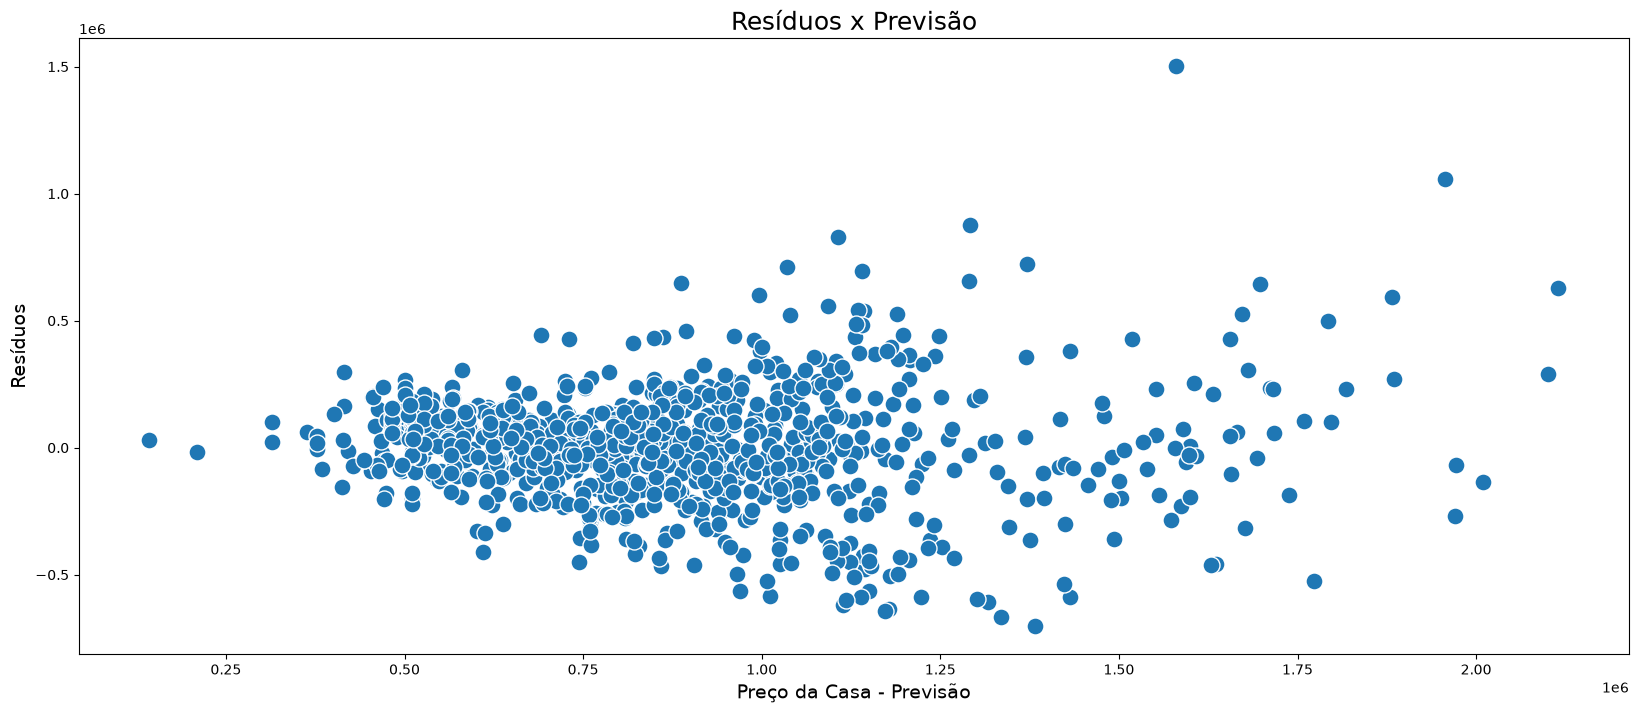

In [60]:
ax = sns.scatterplot(x=y_previsto_treino, y=residuos, s=150)
ax.figure.set_size_inches(20, 8)
ax.set_title('Resíduos x Previsão', fontsize=18)
ax.set_xlabel('Preço da Casa - Previsão', fontsize=14)
ax.set_ylabel('Resíduos', fontsize=14)
ax

In [ ]:
# em preços de casa mais baixos, o modelo está acertando mais, em casas mais caras, 
# os resíduos são maiores